In [ ]:
# !pip install tensorflow
# !pip install pillow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set parameters
img_size = (224, 224)
batch_size = 32

# Load dataset
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/train', target_size=img_size, batch_size=batch_size, class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/test', target_size=img_size, batch_size=batch_size, class_mode='categorical')

# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile and Train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=test_generator, epochs=5)

# Save model
model.save("custom_cnn_model.h5")


Found 928 images belonging to 4 classes.
Found 448 images belonging to 4 classes.


/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 718ms/step - accuracy: 0.2529 - loss: 5.8322 - val_accuracy: 0.2500 - val_loss: 1.3780
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 645ms/step - accuracy: 0.3875 - loss: 1.3304 - val_accuracy: 0.5692 - val_loss: 1.2170
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 632ms/step - accuracy: 0.5855 - loss: 1.0349 - val_accuracy: 0.7545 - val_loss: 0.7027
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 632ms/step - accuracy: 0.7124 - loss: 0.7273 - val_accuracy: 0.8705 - val_loss: 0.5228
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 638ms/step - accuracy: 0.8255 - loss: 0.5425 - val_accuracy: 0.8929 - val_loss: 0.3457


  Using cached pytz-2025.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.1-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 673.9 kB/s eta 0:00:00a 0:00:01
Using cached pytz-2025.1-py2.py3-none-any.whl (507 kB)
Using cached tzdata-2025.1-py2.py3-none-any.whl (346 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 709.4 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 427.9 kB/s eta 0:00:0000:0100:02


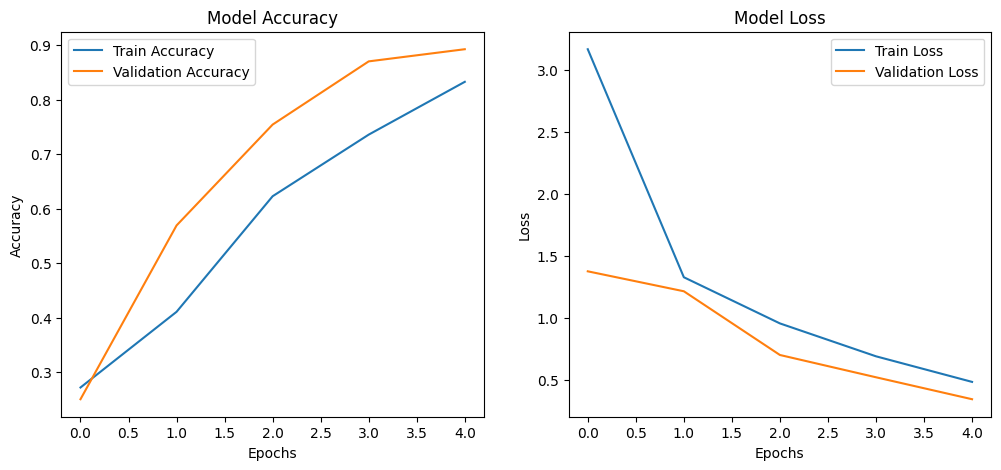

In [ ]:
# !pip install seaborn
# !pip install scikit-learn
#plotting of cnn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Retrieve training history
history = model.history

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()


In [4]:
# Get true labels and predictions
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Get class names
class_labels = list(test_generator.class_indices.keys())

# Print Classification Report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step
                                  precision    recall  f1-score   support

     Patient abnormal heartbeat        0.22      0.19      0.20       112
          Myocardial Infarction        0.21      0.21      0.21       112
              Normal Person ECG        0.31      0.40      0.35       112
Patient that have History of MI        0.27      0.22      0.25       112

                        accuracy                           0.26       448
                       macro avg       0.25      0.26      0.25       448
                    weighted avg       0.25      0.26      0.25       448



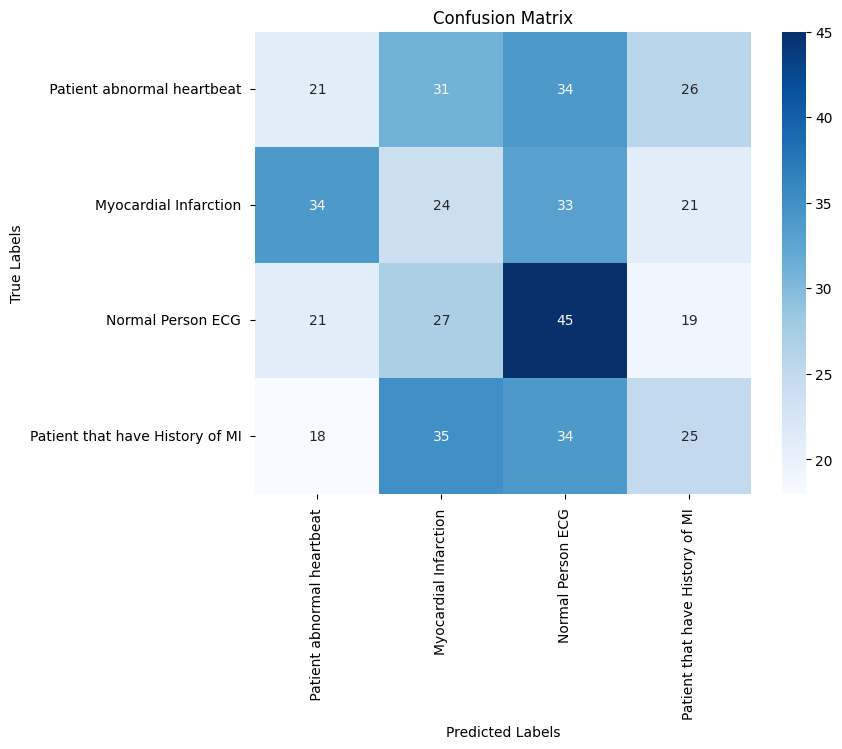

In [5]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [6]:
from sklearn.metrics import f1_score

# Calculate F1-score
f1 = f1_score(y_true, y_pred_classes, average='weighted')
print(f"Weighted F1 Score: {f1:.4f}")


Weighted F1 Score: 0.2522
